#Exercise: Resampling Methods

**Authors:** Sek Huen Leung, Kadri Kalamäe

**Date:** 03.10.2026

First, we are working with the air pollution data set *pollution_cleaneddata.csv* and using resampling methods to evaluate the predictive performance of alternative model choices.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import gdown


gdown.download(
    id="18aKWNsQWvKCFmPijpxNFF8XMMvZcEqPV",
    output="pollution_cleaneddata.csv",
    quiet=True
)

random_seed = 123

In [ ]:
# read in data
data_file = "pollution_cleaneddata.csv"
data = pd.read_csv(data_file, encoding='latin1')
data.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


We specify a polynomial regression model with degree $p$ that predicts mortality as a function of the average July temperature in degrees F.
$$ y_i = \beta_0 + \beta_1 x_i+ \beta_2 x_i^2+\ldots +  \beta_p x_i^p+\varepsilon_i$$

For validation, we split data into two equal sized sets, one for training and one for testing. For polynomial models with degree 1 up to 4, we derive the mean square error of prediction for the training and testing data sets, respectively.


In [ ]:
# polynomial regression model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

def fit_polynomial(x, y, degree):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])

    model.fit(x, y)

    return model

In [ ]:
# validation set
from sklearn.model_selection import train_test_split

x = data[["JULT"]]
y = data["MORT"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.5,
    random_state=random_seed
)

In [ ]:
from sklearn.metrics import mean_squared_error
degrees = range(1, 5)

train_mse = []
test_mse = []

for degree in degrees:

    model = fit_polynomial(x_train, y_train, degree)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # MSE
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

We present the results in a plot with polynomial degree on the x-axis and Mean Square Error on the y-axis. The second-degree polynomial model has the lowest test MSE, so based on this validation set, we would recommend the second-degree model. Although the training MSE decreases substantially for degrees 3 and 4, their test MSE increases slightly, suggesting that the additional model complexity does not improve prediction on unseen data.

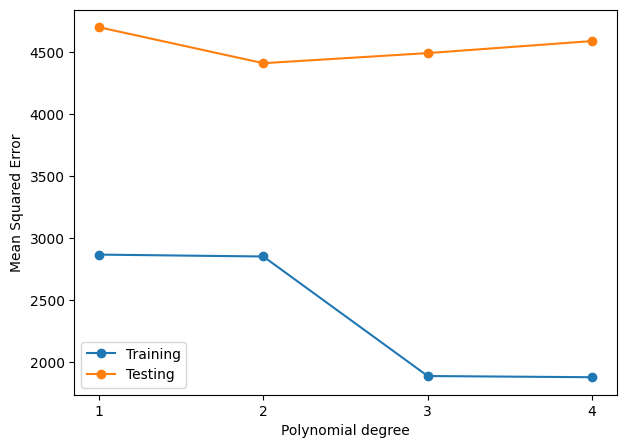

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(degrees, train_mse, marker="o", label="Training")
plt.plot(degrees, test_mse, marker="o", label="Testing")

plt.xlabel("Polynomial degree")
plt.ylabel("Mean Squared Error")
plt.xticks(degrees)
plt.legend()
plt.show()

We repeat the procedure ten times but with other random seeds and analyse whether we get similar results.

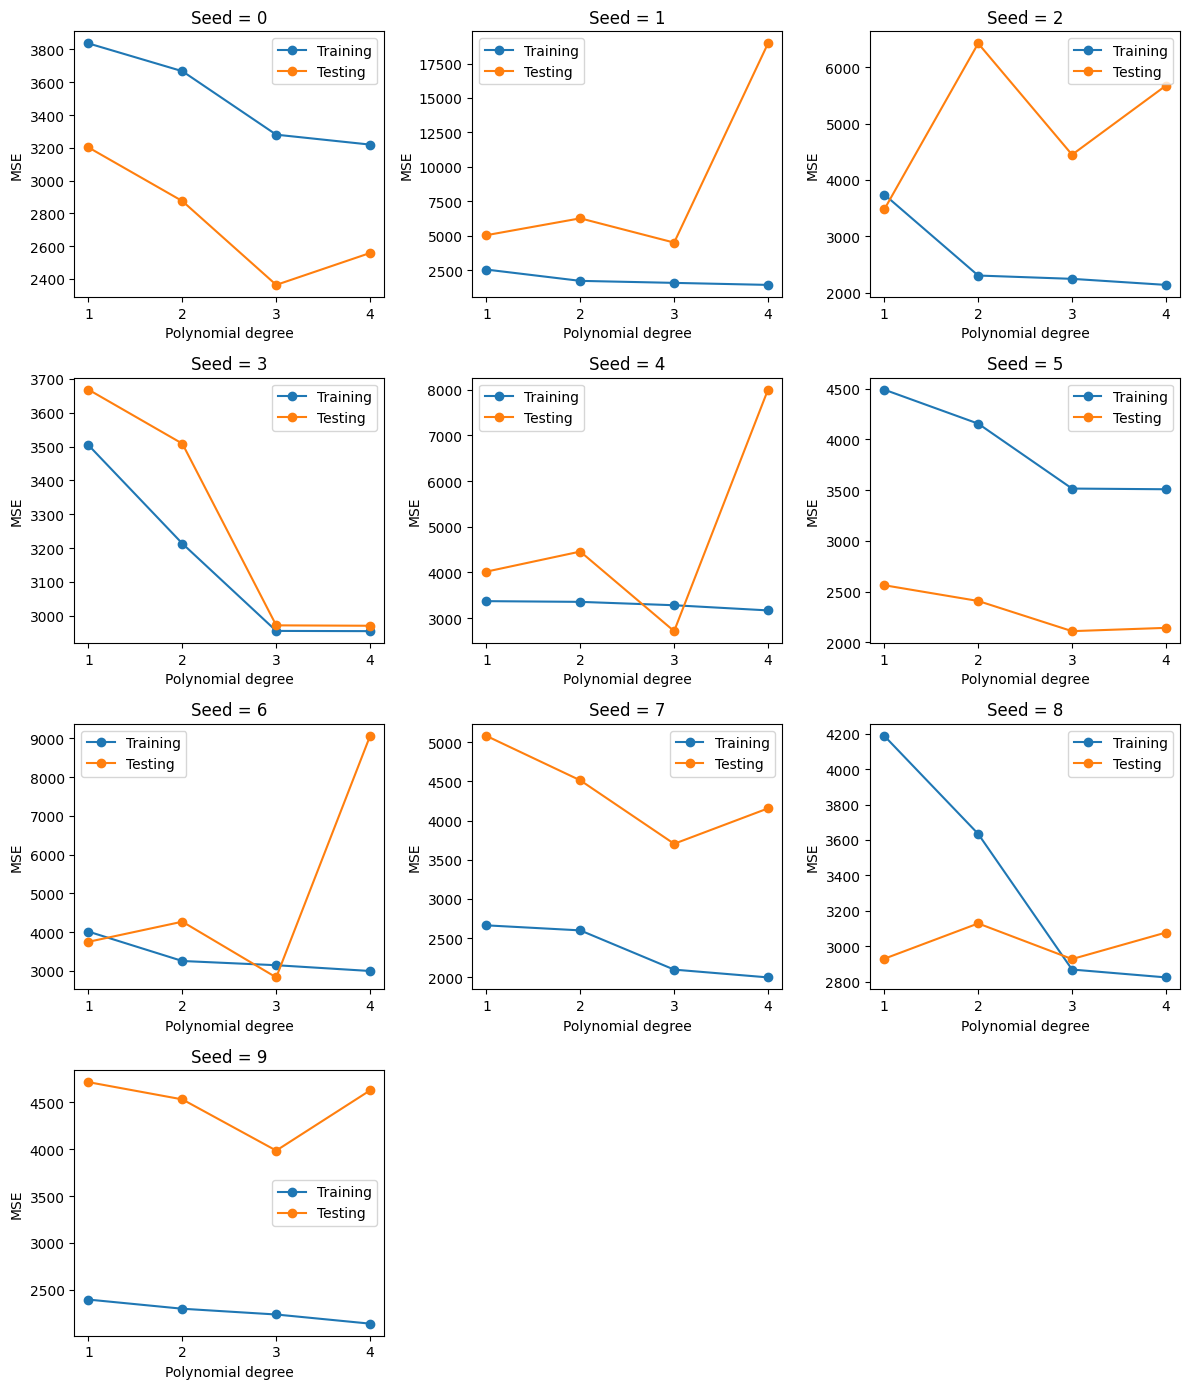

In [ ]:
# Repeat with 10 different random seeds

seeds = range(10)

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
axes = axes.ravel()

for i, seed in enumerate(seeds):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y,
        test_size=0.5,
        random_state=seed
    )

    train_mse_seed = []
    test_mse_seed = []

    for degree in degrees:
        model = fit_polynomial(x_train, y_train, degree)

        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

        train_mse_seed.append(
            mean_squared_error(y_train, y_train_pred)
        )
        test_mse_seed.append(
            mean_squared_error(y_test, y_test_pred)
        )

    axes[i].plot(
        degrees, train_mse_seed,
        marker="o",
        label="Training"
    )

    axes[i].plot(
        degrees, test_mse_seed,
        marker="o",
        label="Testing"
    )

    axes[i].set_title(f"Seed = {seed}")
    axes[i].set_xlabel("Polynomial degree")
    axes[i].set_ylabel("MSE")
    axes[i].set_xticks(degrees)
    axes[i].legend()

# Hide the two unused subplots
for i in range(10, 12):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

The results are not very similar across seeds. The training MSE behaves consistently. It decreases or stays flat as the degree increases, which is expected because higher-degree polynomials can fit the training points more closely. The test MSE, however, depends stongly on the random split. For most seeds the model with 3 degrees has the lowest test MSE, but for seed 2 for example the linear model is best. The second-degree model is never the best, which means our conclusion from the first split (seed 123) does not hold up across seeds. For the degree-4 model the test MSE often blows up suggesting overfitting or a few influential observations ending up in the test set. Across seeds the evidence favours degree 3.

Now, we select a polynomial degree $p=2$ and estimate the variance of predictions using the K-fold cross-validation approach with $K=3$ hold out sets.

In [ ]:
# K-fold
from sklearn.model_selection import KFold

degree = 2

kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=random_seed
)

test_mse_cv = []

for train_index, test_index in kf.split(x):

    x_train = x.iloc[train_index]
    x_test = x.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = fit_polynomial(x_train, y_train, degree)

    y_test_pred = model.predict(x_test)

    test_mse_cv.append(
        mean_squared_error(y_test, y_test_pred)
    )

print("MSE for each fold:", test_mse_cv)
print("Mean CV MSE:", np.mean(test_mse_cv))

MSE for each fold: [5565.847931776055, 2955.0525324870187, 5269.557366758516]
Mean CV MSE: 4596.819277007196


We repeat the procedure ten times but with other random seeds.

[np.float64(4049.4894374549326), np.float64(5175.994078204877), np.float64(5176.310229255297), np.float64(3513.0298772157694), np.float64(3826.8037940926683), np.float64(3924.199874134452), np.float64(5740.597705176036), np.float64(3758.749368499893), np.float64(3576.5170642300104), np.float64(5723.806749641201)]
4446.549817790514 899.79391868499


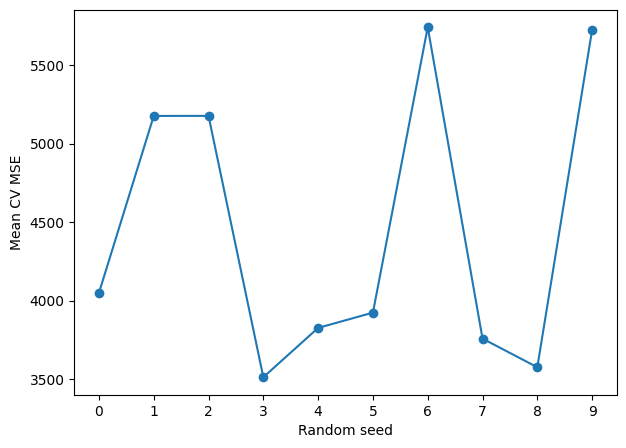

In [ ]:
seeds = range(10)

cv_mse = []

for seed in seeds:

    kf = KFold(
        n_splits=3,
        shuffle=True,
        random_state=seed
    )

    fold_mse = []

    for train_index, test_index in kf.split(x):

        x_train = x.iloc[train_index]
        x_test = x.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = fit_polynomial(x_train, y_train, degree)

        y_test_pred = model.predict(x_test)

        fold_mse.append(
            mean_squared_error(y_test, y_test_pred)
        )

    cv_mse.append(np.mean(fold_mse))

print(cv_mse)
print(np.mean(cv_mse), np.std(cv_mse, ddof=1))

plt.figure(figsize=(7, 5))

plt.plot(seeds, cv_mse, marker="o")

plt.xlabel("Random seed")
plt.ylabel("Mean CV MSE")
plt.xticks(seeds)
plt.show()

The mean CV MSE across seeds is about 4447, with a standard deviation of about 900. The results are similar in order of magnitude, but not stable. With only 60 observations, each test fold has only 20 points, so each fold's MSE is a noisy average. It may also be that there are some high-leverage or high-residual observations in the dataset and if those land in a test fold, that fold's squared errors blow up, and they dominate the average.

Now, we use the bootstrap to estimate the standard error of the slope of the line in the Poisson regression of the birds over time. First, let's load the data set *bird_count.csv*.

In [ ]:
# read in data

gdown.download(
    id="1OrcbfMsqtZn-3S0ed3TGJnFT-2rVTv3v",
    output="bird_count.csv",
    quiet=True
)

bird_data = pd.read_csv("bird_count.csv")

bird_data.head()

,count,yr,observerAge,lineCov
0,2,2011,63,1.000000
1,5,2010,64,0.987500
2,12,2002,30,0.991667
3,12,2006,60,0.987500
4,5,2008,62,0.987500


We retrieve the Poisson model fitted with maximum likelihood from an earlier assignment in the course.

In [ ]:
# Poisson regression log likelihood
def poi_log_l(beta_, x_, y_):
  # minus sign added in front because later we minimize the function
  # minimizing -log L is equivalent to maximizing log L
  # -log(y!) term is dropped since it doesn't depend on beta and so doesn't affect the argmax
  return -np.sum(-np.exp(beta_[0]+beta_[1]*x_)+y_*(beta_[0]+beta_[1]*x_))

# Poisson regression
def poi_reg(y_, x_):
  x0 = np.array([0.,0.1]) # initial values for beta
  res = minimize(poi_log_l,x0,args=(x_, y_))
  beta_ = res.x
  return beta_

# Poisson prediction
def poi_pred(x_, beta_):
  mu_ = np.exp(beta_[0]+ beta_[1]*x_)
  y_hat = poisson.rvs(mu_)
  return y_hat

In [ ]:
y_bird = bird_data["count"].to_numpy()

x_bird = bird_data["yr"].to_numpy()
x_bird = x_bird - 1999

In [ ]:
beta_ = poi_reg(y_bird, x_bird)
print("Estimated parameters:")
print(beta_)

Estimated parameters:
[ 2.32533193 -0.03244318]


Using maximum likelihood based on all data, the estimate of the parameter is $\hat{\beta}_1=-0.03244$. Now, we use the bootstrap to approximate the standard error of the estimate of the slope parameter.

In [ ]:
# Bootstrap
B = 10000
rng = np.random.default_rng(42)

bootstrap_beta1 = []

n = len(y_bird)

for b in range(B):

    # Sample indices with replacement
    index = rng.choice(n, size=n, replace=True)

    # Bootstrap sample
    x_boot = x_bird[index]
    y_boot = y_bird[index]

    # Fit Poisson regression
    beta_boot = poi_reg(y_boot, x_boot)

    # Save the slope beta_1
    bootstrap_beta1.append(beta_boot[1])

bootstrap_beta1 = np.array(bootstrap_beta1)

# Bootstrap standard error
bootstrap_se = np.std(bootstrap_beta1, ddof=1)

print("Bootstrap SE of beta_1:", bootstrap_se)

Bootstrap SE of beta_1: 0.03453053884667915


When taking the standard deviation of the bootstrap sample of the slope parameter we get 0.034531.

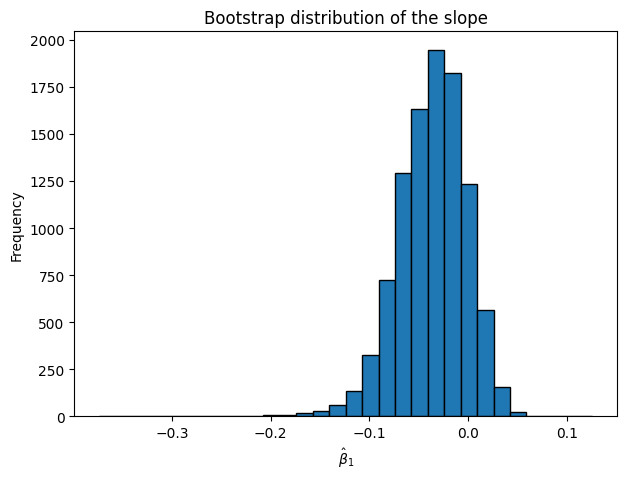

In [ ]:
plt.figure(figsize=(7, 5))

plt.hist(bootstrap_beta1, bins=30, edgecolor="black")

plt.xlabel(r"$\hat{\beta}_1$")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of the slope")

plt.show()